# Exercise B.2 — Memetic Algorithms for TSP

This notebook compares a **simple EA** and a **memetic algorithm (MA)** for the Travelling Salesman Problem.

The MA extends the EA with **2-opt local search** applied to each offspring.

**EA configuration:**
- Permutation representation
- Tournament selection (K=5)
- Order crossover (OX) with p_c = 0.8
- Swap mutation with probability mu = 0.3
- Population size N = 100
- Generational replacement, no elitism

**Datasets:**
1. `file-tsp.txt` — 50 cities (custom instance)
2. TSPLIB benchmark instance (download a `.tsp` file and place it in this directory)

**Code structure:**
- `tsp_ea.py` — Core EA/MA (selection, crossover, mutation, 2-opt, runners)
- `experiments_b2.py` — Experiment runners for generation-based and time-based comparisons
- `plotting_b2.py` — Visualization functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tsp_ea import (
    load_tsp_coordinates,
    load_tsplib,
    compute_distance_matrix,
    tour_distance,
    run_ea,
    run_ma,
)
from experiments_b2 import (
    load_dataset,
    experiment_generations,
    experiment_timed,
)
from plotting_b2 import (
    plot_convergence_generations,
    plot_convergence_timed,
    plot_final_distances,
    plot_tour,
    plot_time_comparison,
    summary_table,
)

N_RUNS = 10
N_POP = 100
G_MAX = 200
K = 5
P_C = 0.8
MU = 0.3

## Load datasets

In [2]:
# Dataset 1: custom 50-city instance
coords_custom, dist_custom = load_dataset("file-tsp", "file-tsp.txt")
print(f"Custom dataset: {len(coords_custom)} cities")

# Dataset 2: TSPLIB instance
# Download a .tsp file from http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/
# e.g., eil51.tsp, berlin52.tsp, or att48.tsp
TSPLIB_FILE = "eil51.tsp"  # <-- change this to your downloaded file
coords_tsplib, dist_tsplib = load_dataset("tsplib", TSPLIB_FILE)
print(f"TSPLIB dataset: {len(coords_tsplib)} cities")

Custom dataset: 50 cities
TSPLIB dataset: 51 cities


## B.2.1 — Generation-based comparison (same generations, unfair)

First, we compare EA and MA using the **same number of generations**.
This is intentionally unfair: the MA performs additional 2-opt local search
each generation, consuming significantly more wall-clock time per generation.

### Dataset 1: custom 50-city instance

In [3]:
results_gen_custom = experiment_generations(
    dist_custom, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA...
    Run 1/10: best = 169.89, time = 0.3s
    Run 2/10: best = 164.22, time = 0.3s
    Run 3/10: best = 157.10, time = 0.3s
    Run 4/10: best = 160.84, time = 0.3s
    Run 5/10: best = 171.25, time = 0.3s
    Run 6/10: best = 177.79, time = 0.3s
    Run 7/10: best = 158.51, time = 0.3s
    Run 8/10: best = 178.46, time = 0.3s
    Run 9/10: best = 169.96, time = 0.3s
    Run 10/10: best = 158.74, time = 0.3s
  Running memetic algorithm (EA + 2-opt)...
    Run 1/10: best = 119.94, time = 21.4s
    Run 2/10: best = 120.38, time = 20.3s
    Run 3/10: best = 119.94, time = 21.6s
    Run 4/10: best = 119.94, time = 21.4s
    Run 5/10: best = 120.68, time = 20.4s
    Run 6/10: best = 119.94, time = 20.8s
    Run 7/10: best = 119.94, time = 20.6s
    Run 8/10: best = 119.94, time = 20.8s
    Run 9/10: best = 119.94, time = 20.5s
    Run 10/10: best = 119.94, time = 20.9s


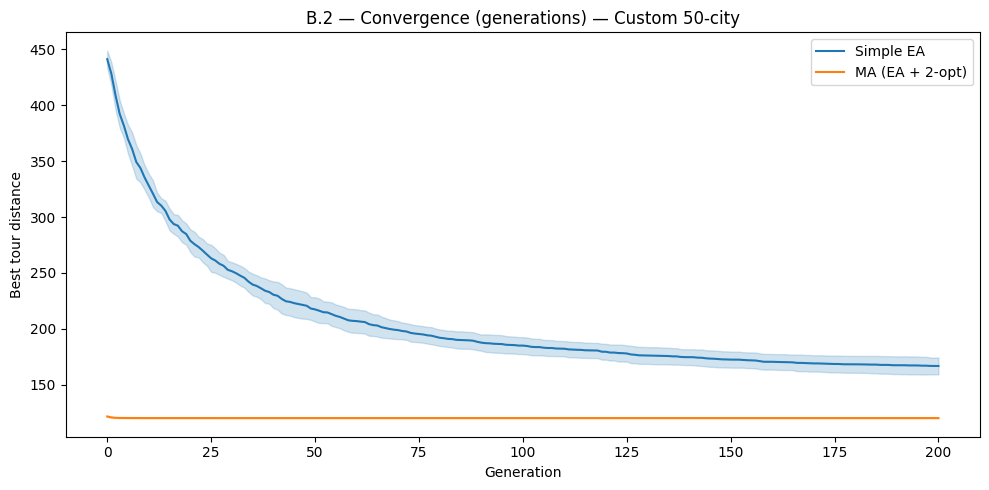

In [4]:
fig = plot_convergence_generations(
    results_gen_custom, title="B.2 — Convergence (generations) — Custom 50-city")
plt.show()

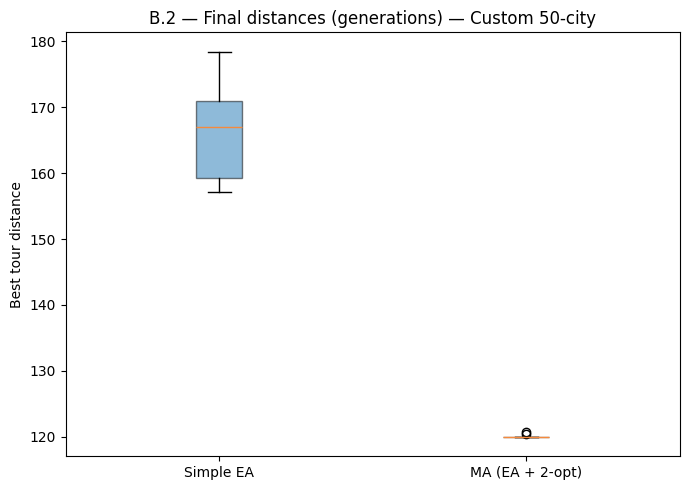

In [5]:
fig = plot_final_distances(
    results_gen_custom, title="B.2 — Final distances (generations) — Custom 50-city")
plt.show()

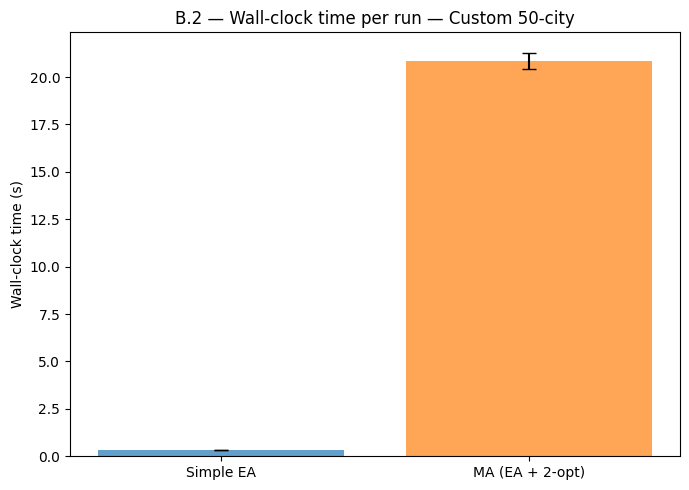

In [6]:
fig = plot_time_comparison(
    results_gen_custom, title="B.2 — Wall-clock time per run — Custom 50-city")
plt.show()

In [7]:
summary_table(results_gen_custom, "Custom 50-city (generation-based)")


  Custom 50-city (generation-based)
  Simple EA:
    Best distance: 157.10
    Mean distance: 166.67 +/- 7.52
    Mean time:     0.3s
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 120.06 +/- 0.24
    Mean time:     20.9s



### Dataset 2: TSPLIB instance

In [8]:
results_gen_tsplib = experiment_generations(
    dist_tsplib, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA...
    Run 1/10: best = 617.28, time = 0.3s
    Run 2/10: best = 542.05, time = 0.3s
    Run 3/10: best = 539.28, time = 0.3s
    Run 4/10: best = 527.95, time = 0.3s
    Run 5/10: best = 589.42, time = 0.3s
    Run 6/10: best = 593.40, time = 0.3s
    Run 7/10: best = 551.02, time = 0.3s
    Run 8/10: best = 575.60, time = 0.3s
    Run 9/10: best = 614.91, time = 0.3s
    Run 10/10: best = 601.37, time = 0.3s
  Running memetic algorithm (EA + 2-opt)...
    Run 1/10: best = 428.98, time = 22.0s
    Run 2/10: best = 428.87, time = 21.2s
    Run 3/10: best = 428.87, time = 21.5s
    Run 4/10: best = 428.98, time = 21.4s
    Run 5/10: best = 428.98, time = 21.4s
    Run 6/10: best = 428.87, time = 20.2s
    Run 7/10: best = 428.98, time = 21.3s
    Run 8/10: best = 429.53, time = 20.6s
    Run 9/10: best = 428.87, time = 20.4s
    Run 10/10: best = 428.98, time = 21.8s


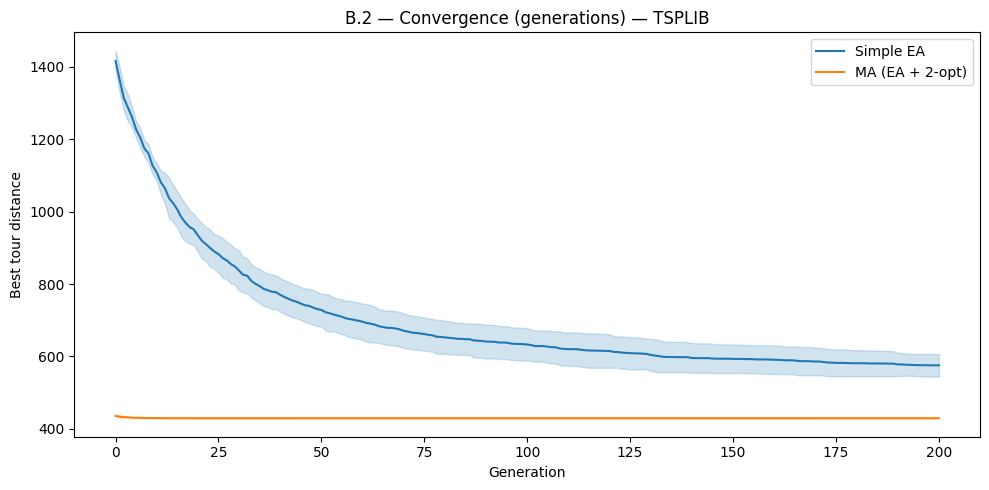

In [9]:
fig = plot_convergence_generations(
    results_gen_tsplib, title="B.2 — Convergence (generations) — TSPLIB")
plt.show()

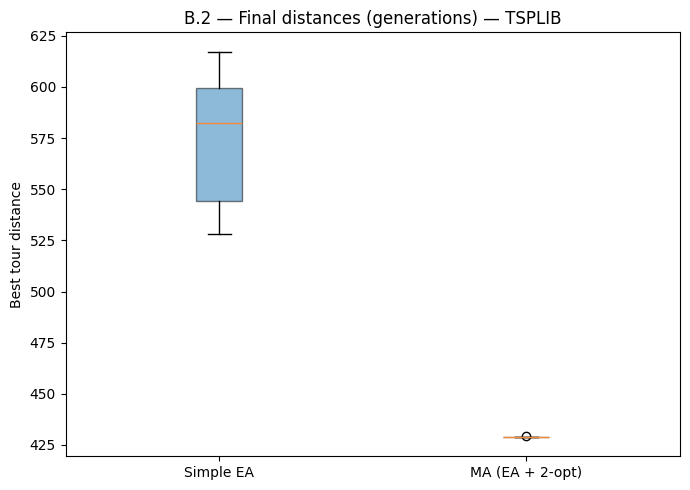

In [10]:
fig = plot_final_distances(
    results_gen_tsplib, title="B.2 — Final distances (generations) — TSPLIB")
plt.show()

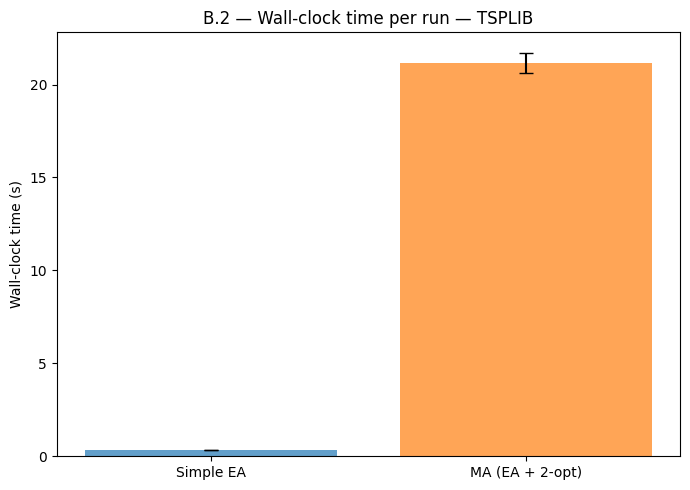

In [11]:
fig = plot_time_comparison(
    results_gen_tsplib, title="B.2 — Wall-clock time per run — TSPLIB")
plt.show()

In [12]:
summary_table(results_gen_tsplib, "TSPLIB (generation-based)")


  TSPLIB (generation-based)
  Simple EA:
    Best distance: 527.95
    Mean distance: 575.23 +/- 31.26
    Mean time:     0.3s
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 428.99 +/- 0.19
    Mean time:     21.2s



## B.2.1 Discussion — Is same-generation comparison fair?

Comparing EA and MA with the same number of generations is **not a fair comparison**.

The MA performs 2-opt local search on every offspring, which is computationally
expensive. Even though both algorithms run the same number of generations, the MA
uses orders of magnitude more wall-clock time (as shown in the bar chart above).

A fairer comparison gives both algorithms the same **wall-clock time budget**, so
the EA can run many more generations to compensate for not having local search.
This equalizes the total computational resources available to each algorithm.

## B.2.2 — Time-based comparison (fair)

We give both algorithms the same wall-clock time budget.
The budget is set to the mean time the MA used in the generation-based experiment,
so the MA runs roughly the same number of generations as before, while the EA
gets many more generations to compensate.

In [13]:
# Use the MA's wall-clock time from generation-based runs as the budget
time_budget_custom = np.mean([r["elapsed"] for r in results_gen_custom["ma"]])
time_budget_tsplib = np.mean([r["elapsed"] for r in results_gen_tsplib["ma"]])
print(f"Time budget for custom dataset: {time_budget_custom:.1f}s")
print(f"Time budget for TSPLIB dataset: {time_budget_tsplib:.1f}s")

Time budget for custom dataset: 20.9s
Time budget for TSPLIB dataset: 21.2s


### Dataset 1: custom 50-city instance

In [14]:
results_timed_custom = experiment_timed(
    dist_custom, n_runs=N_RUNS, time_budget=time_budget_custom,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (time budget = 20.856981182098387s)...
    Run 1/10: best = 137.73, gens = 12695
    Run 2/10: best = 139.28, gens = 12742
    Run 3/10: best = 174.49, gens = 12820
    Run 4/10: best = 143.51, gens = 12809
    Run 5/10: best = 168.98, gens = 12795
    Run 6/10: best = 154.32, gens = 12772
    Run 7/10: best = 161.31, gens = 12777
    Run 8/10: best = 154.09, gens = 12712
    Run 9/10: best = 156.64, gens = 12832
    Run 10/10: best = 160.05, gens = 12912
  Running MA (time budget = 20.856981182098387s)...
    Run 1/10: best = 119.94, gens = 197
    Run 2/10: best = 119.94, gens = 198
    Run 3/10: best = 119.94, gens = 203
    Run 4/10: best = 119.94, gens = 198
    Run 5/10: best = 119.94, gens = 195
    Run 6/10: best = 119.94, gens = 195
    Run 7/10: best = 119.94, gens = 214
    Run 8/10: best = 119.94, gens = 201
    Run 9/10: best = 119.94, gens = 207
    Run 10/10: best = 119.94, gens = 208


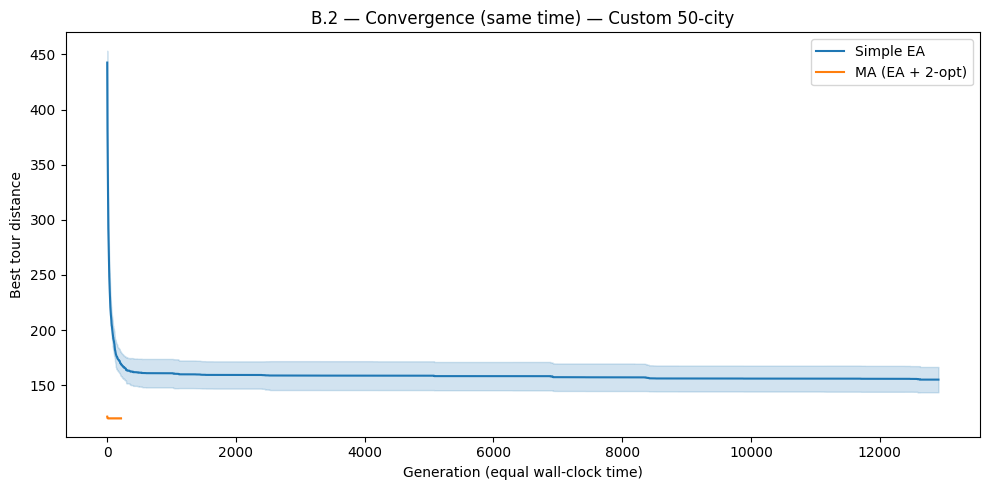

In [15]:
fig = plot_convergence_timed(
    results_timed_custom, title="B.2 — Convergence (same time) — Custom 50-city")
plt.show()

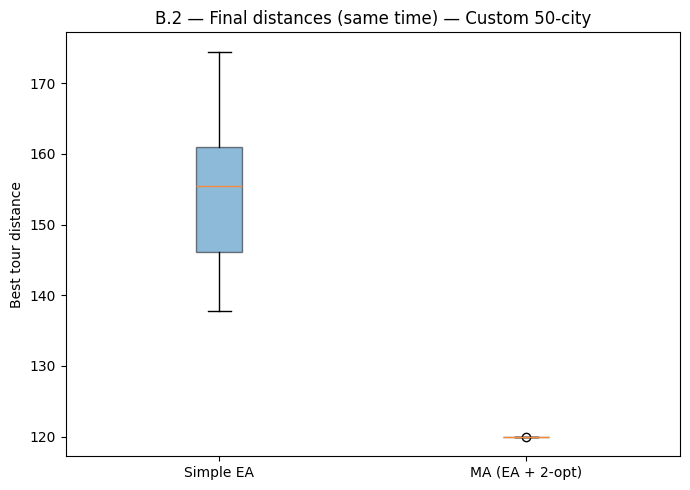

In [16]:
fig = plot_final_distances(
    results_timed_custom, title="B.2 — Final distances (same time) — Custom 50-city")
plt.show()

In [17]:
summary_table(results_timed_custom, "Custom 50-city (time-based)")


  Custom 50-city (time-based)
  Simple EA:
    Best distance: 137.73
    Mean distance: 155.04 +/- 11.50
    Mean gens:     12787
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 119.94 +/- 0.00
    Mean gens:     202



### Dataset 2: TSPLIB instance

In [18]:
results_timed_tsplib = experiment_timed(
    dist_tsplib, n_runs=N_RUNS, time_budget=time_budget_tsplib,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (time budget = 21.16969473361969s)...
    Run 1/10: best = 537.19, gens = 12928
    Run 2/10: best = 514.33, gens = 12956
    Run 3/10: best = 519.39, gens = 12989
    Run 4/10: best = 511.10, gens = 12948
    Run 5/10: best = 462.14, gens = 12956
    Run 6/10: best = 529.01, gens = 12964
    Run 7/10: best = 591.80, gens = 12963
    Run 8/10: best = 578.15, gens = 12963
    Run 9/10: best = 520.15, gens = 12959
    Run 10/10: best = 525.98, gens = 12929
  Running MA (time budget = 21.16969473361969s)...
    Run 1/10: best = 428.98, gens = 206
    Run 2/10: best = 428.98, gens = 197
    Run 3/10: best = 428.98, gens = 201
    Run 4/10: best = 428.87, gens = 201
    Run 5/10: best = 429.53, gens = 210
    Run 6/10: best = 429.53, gens = 214
    Run 7/10: best = 428.98, gens = 208
    Run 8/10: best = 428.87, gens = 166
    Run 9/10: best = 428.98, gens = 175
    Run 10/10: best = 429.12, gens = 177


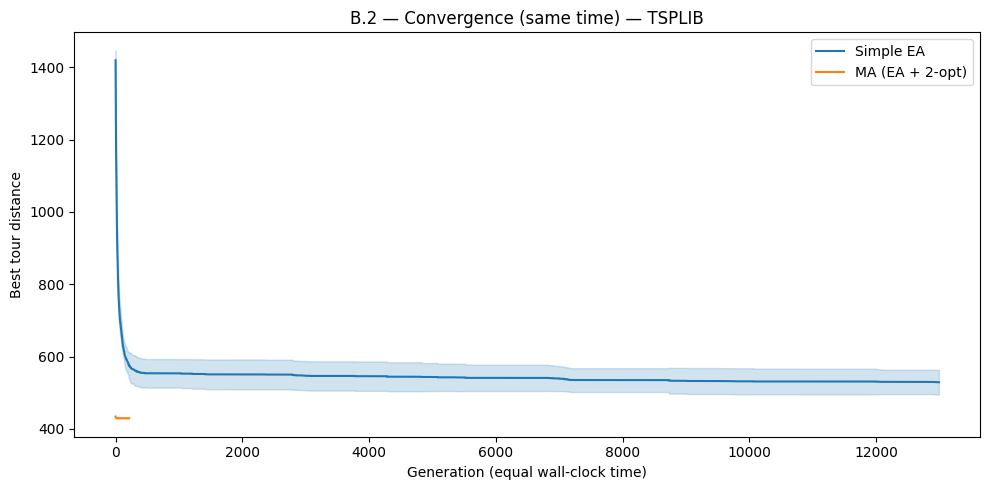

In [19]:
fig = plot_convergence_timed(
    results_timed_tsplib, title="B.2 — Convergence (same time) — TSPLIB")
plt.show()

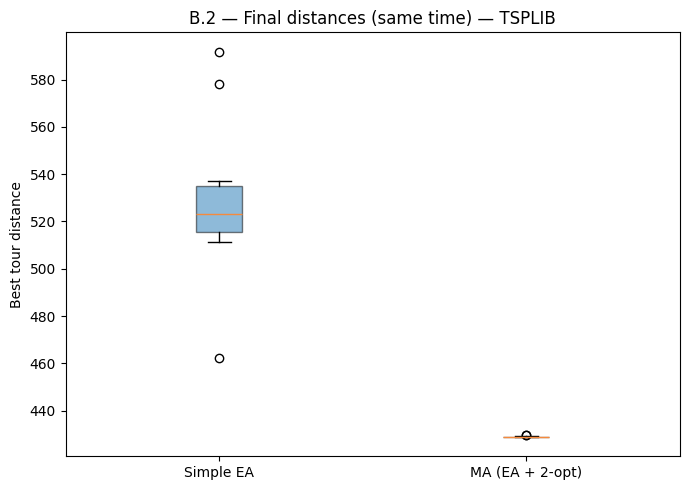

In [20]:
fig = plot_final_distances(
    results_timed_tsplib, title="B.2 — Final distances (same time) — TSPLIB")
plt.show()

In [21]:
summary_table(results_timed_tsplib, "TSPLIB (time-based)")


  TSPLIB (time-based)
  Simple EA:
    Best distance: 462.14
    Mean distance: 528.92 +/- 34.08
    Mean gens:     12956
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 429.08 +/- 0.23
    Mean gens:     196



## Discussion

**Does the addition of local search improve performance?**

- In the **generation-based** (unfair) comparison, the MA clearly outperforms the simple EA, but it also uses far more computation time due to 2-opt.
- In the **time-based** (fair) comparison, both algorithms get the same wall-clock time. The EA can run many more generations, but the MA typically still produces better solutions because 2-opt efficiently exploits the local neighbourhood of each solution.
- The key insight is that local search and evolutionary search are complementary: the EA provides global exploration (crossover recombines diverse tours), while 2-opt provides local exploitation (removes crossing edges). Together they outperform either approach alone, even when given equal computational resources.